# Data blocking

In this notebook I inspect the output of one strain-stress simulation with MACE potential, inspect the output, demonstrate data-blocking, and fix the analysis pipeline.

In [1]:
!which python

/home/gabrielecolombo/Thesis/PROJECT/.venv/bin/python


In [2]:
import numpy as np
import pandas as pd

from lammps_logfile import read_log

import matplotlib.pyplot as plt

from scipy.signal import periodogram, correlate

from ase.io import write

## Load data

Load and check everything is as expected.

In [3]:
thermo = read_log("STRAINSTRESS/merged_strain_stress_xx.out")


In [4]:
thermo.keys()

Index(['Step', 'Temp', 'E_pair', 'E_mol', 'TotEng', 'Press', 'run_num', 'Lx',
       'Ly', 'Lz', 'Xy', 'Xz', 'Yz', 'v_exx', 'v_eyy', 'v_ezz', 'v_gxy',
       'v_gxz', 'v_gyz', 'c_press_compute[1]', 'c_press_compute[2]',
       'c_press_compute[3]', 'c_press_compute[4]', 'c_press_compute[5]',
       'c_press_compute[6]'],
      dtype='object')

## Correlation time

In [5]:
pe = np.array(thermo['PotEng'])
ndata = pe.size
timestep = 1e-3 # ps
times = np.linspace(0, ndata, ndata) * timestep

KeyError: 'PotEng'

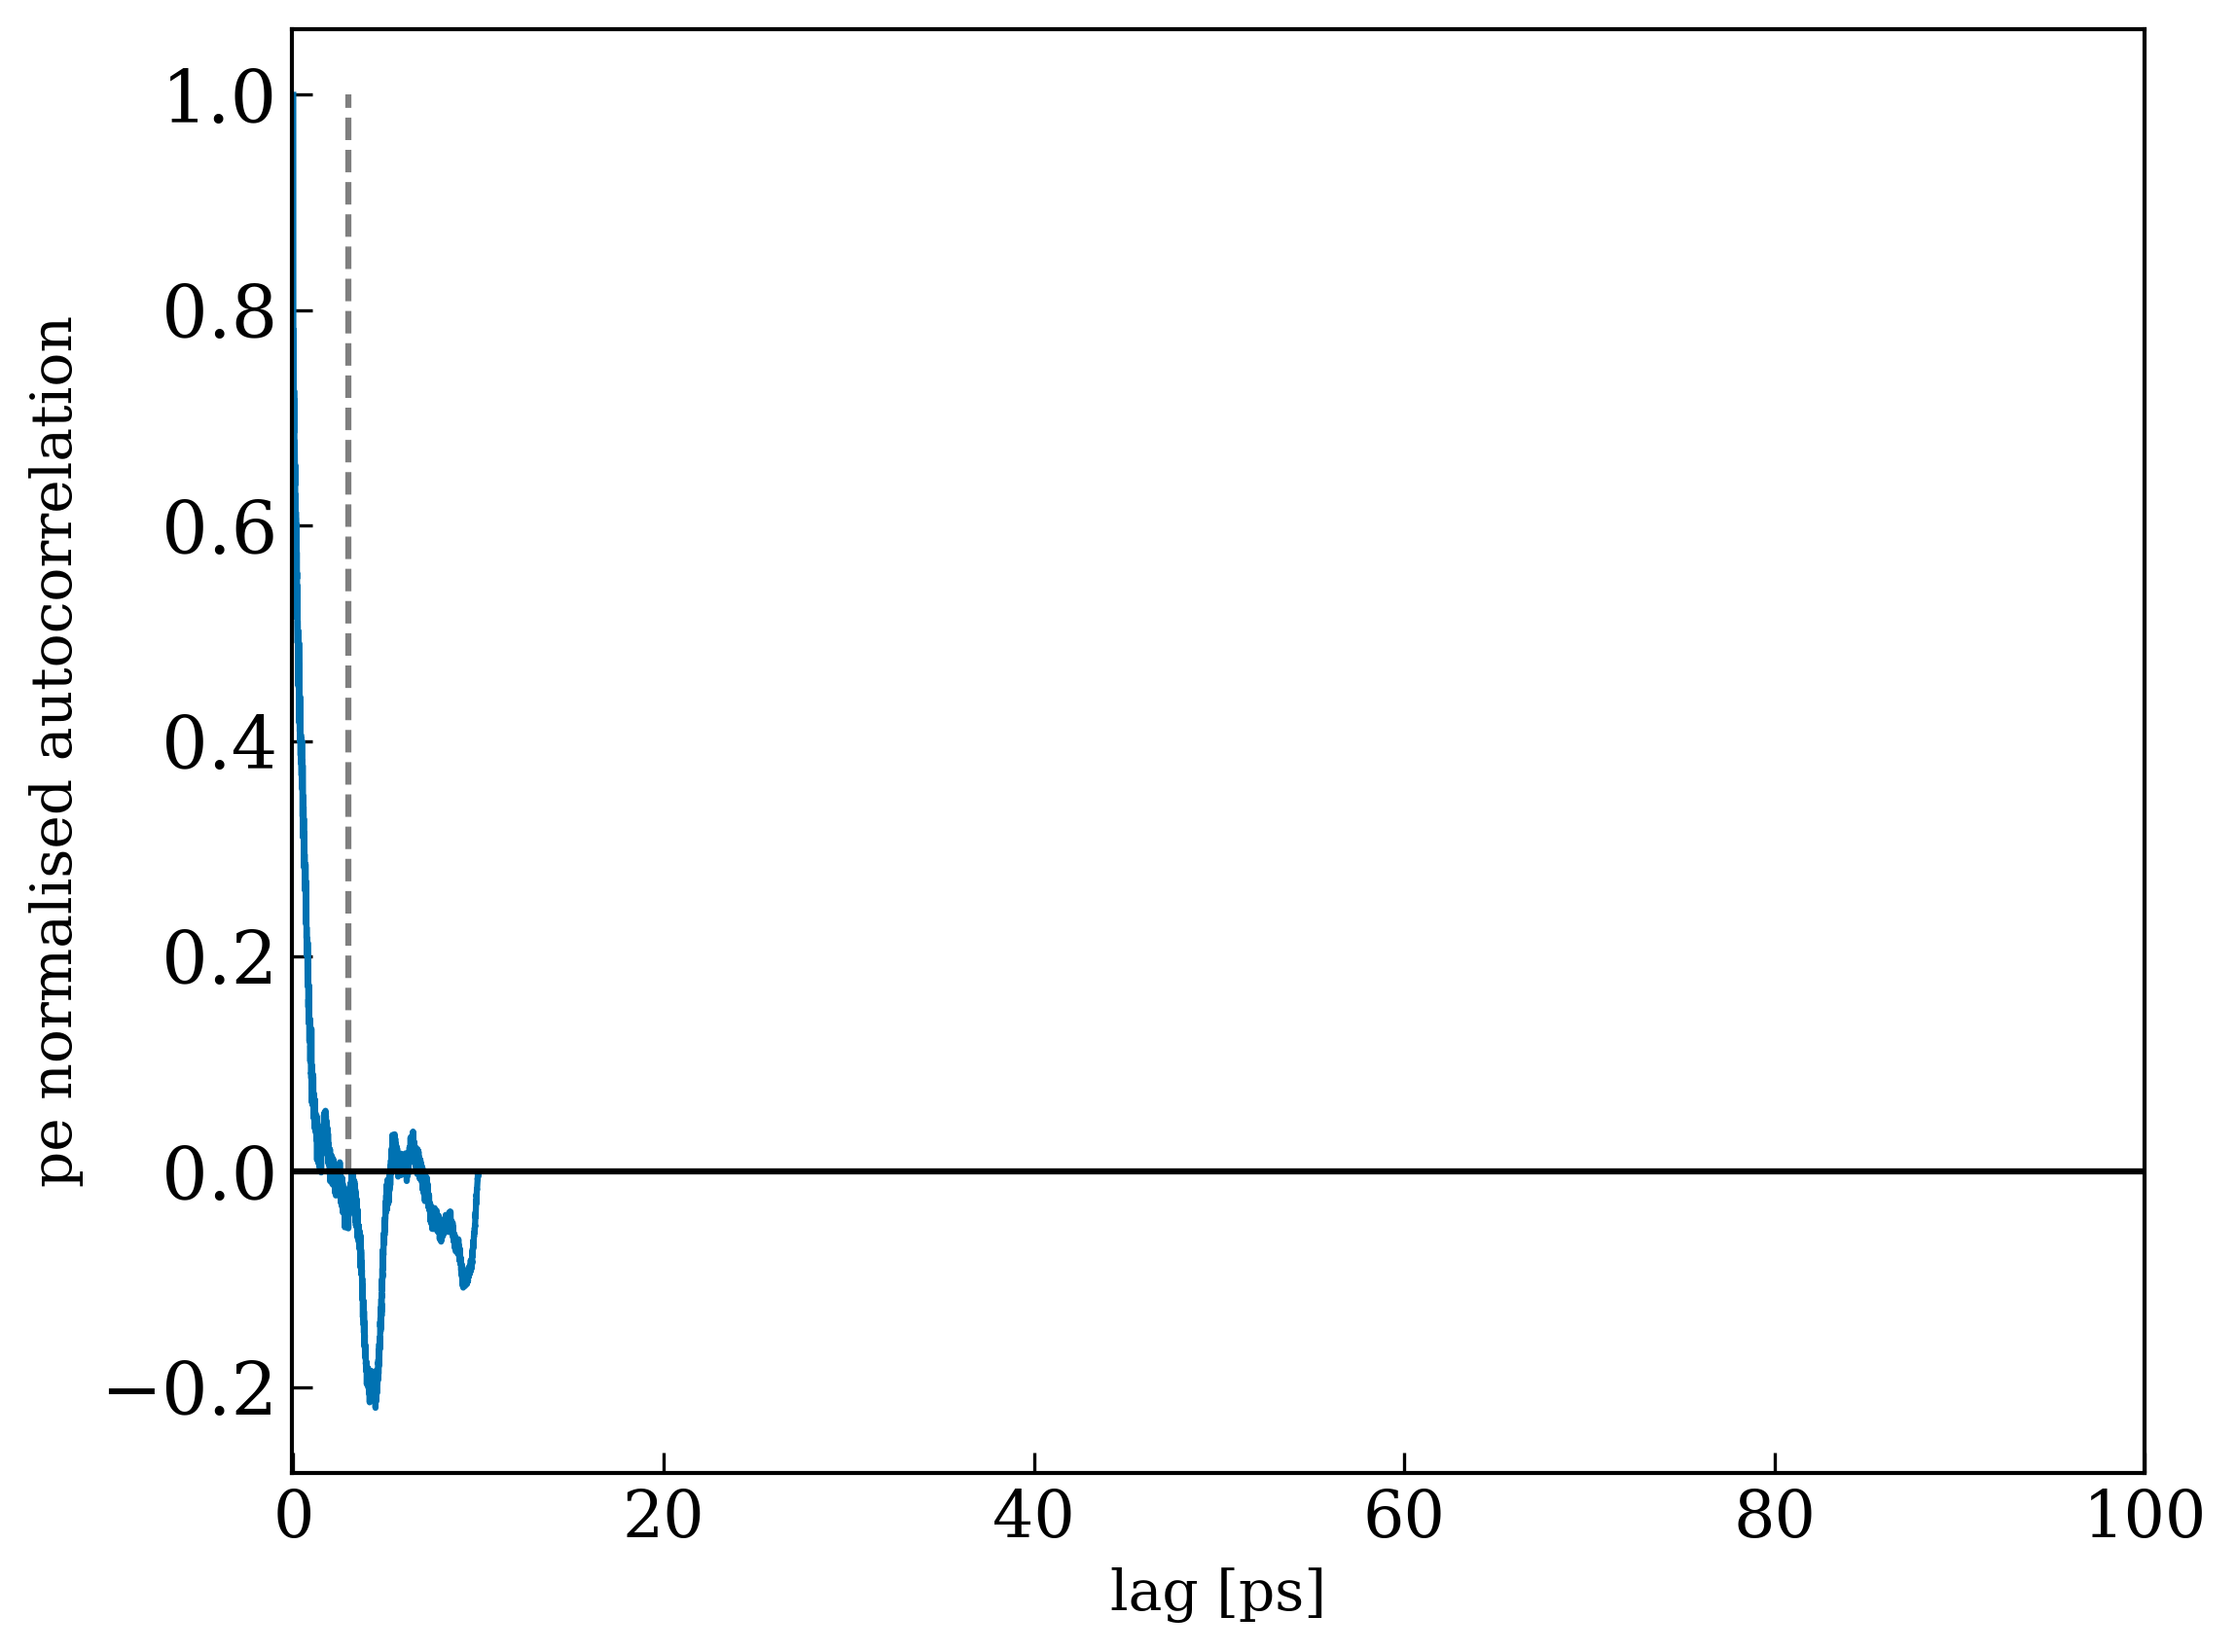

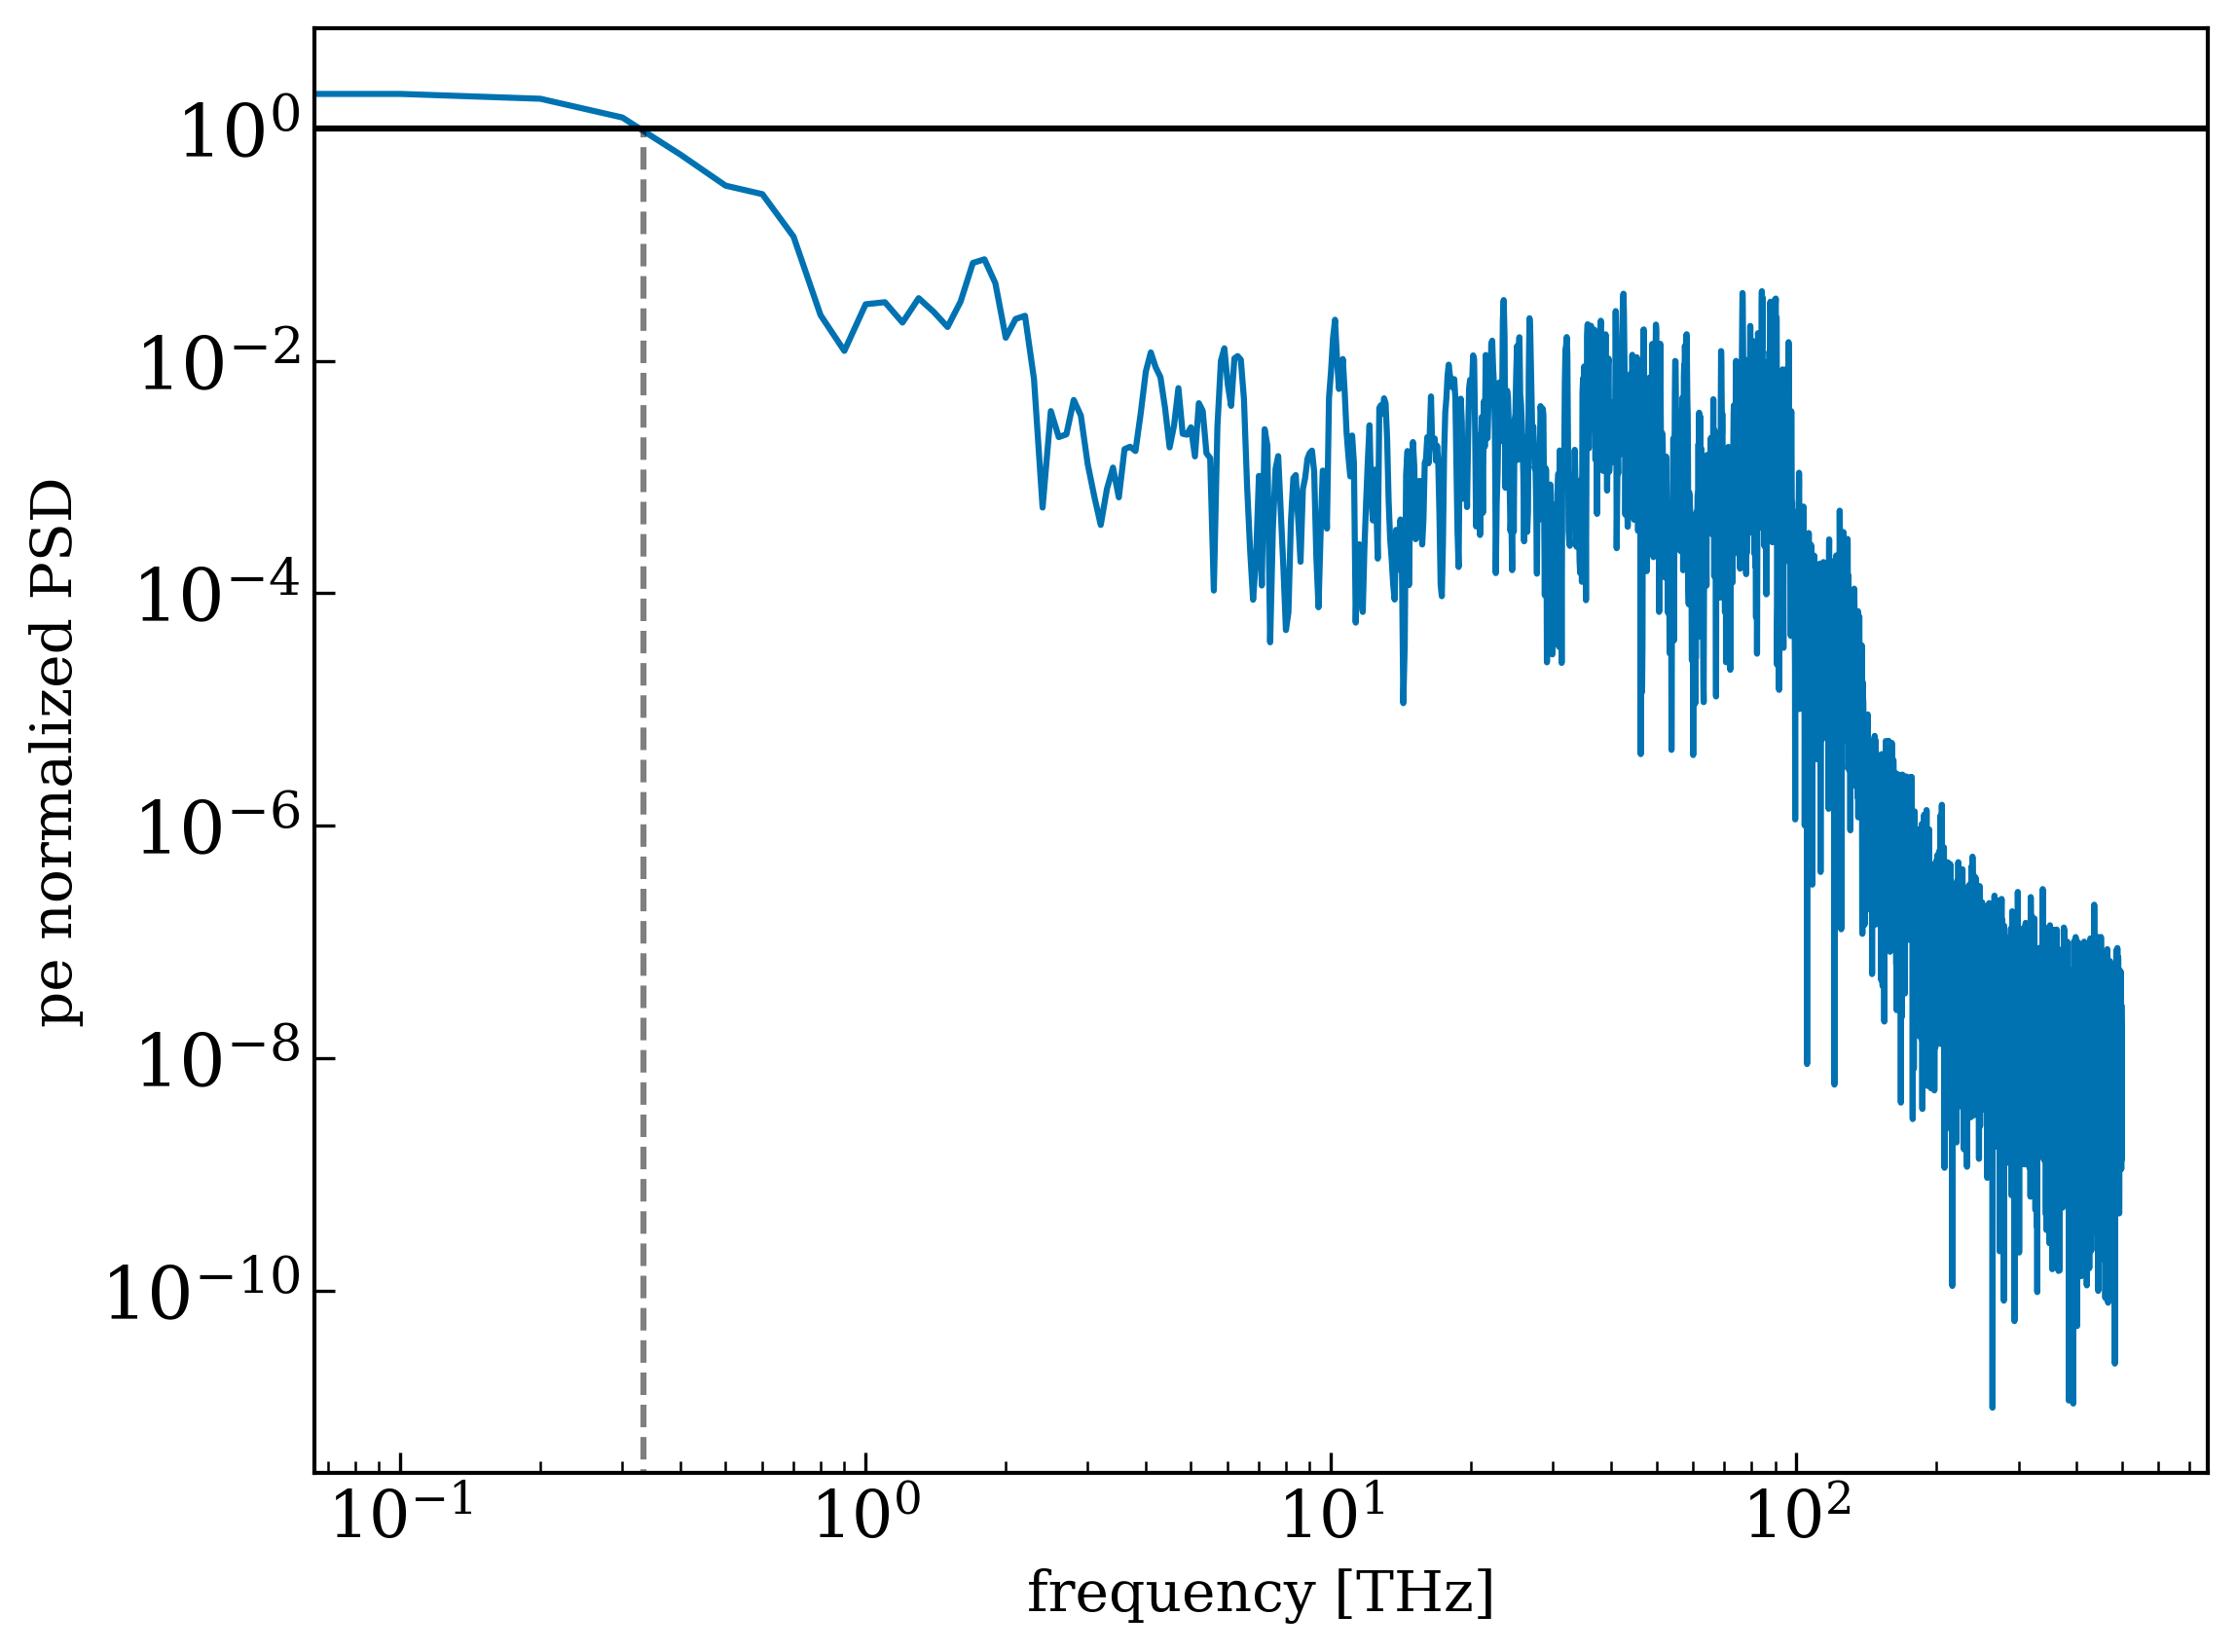

In [ ]:
# remove the mean
unbiased_data = pe - np.mean(pe)
autocorrelation = correlate(unbiased_data, unbiased_data, "full")[ndata-1:]
autocorrelation /= autocorrelation[0]
sampling_freq = 1/timestep


from scipy.signal.windows import gaussian

fs, psd = periodogram(unbiased_data, sampling_freq, return_onesided=True, window="blk")
psd /= psd[0]

axs = [None, None]
fig0, axs[0] = plt.subplots(1,1, figsize = (8,6))
fig1, axs[1] = plt.subplots(1,1, figsize = (8,6))


axs[0].plot(times, autocorrelation)
axs[0].set_xlabel("lag [ps]", fontsize=14)
axs[0].set_ylabel("pe normalised autocorrelation", fontsize=14)
axs[0].set_xlim(-0.1, 100)
axs[0].hlines(0, 0, 100, colors="k")
axs[0].vlines(3, 0, 1, color = "k", alpha=0.5, linestyle="--", linewidth = 1.5)
axs[0].grid()

fig0.tight_layout()
fig0.savefig("pe_autocorrelation.svg")

axs[1].plot(fs, psd)
axs[1].set_yscale("log")
axs[1].set_xscale("log")
axs[1].set_xlabel("frequency [THz]", fontsize = 14)
axs[1].set_ylabel("pe normalized PSD", fontsize = 14)


axs[1].hlines(1, 0, 1000, colors="k")
axs[1].vlines(1./3., 0, 1, color = "k", alpha=0.5, linestyle="--", linewidth = 1.5)
axs[1].grid()

fig1.tight_layout()
fig1.savefig("pe_psd.svg")


In [ ]:
from data_blocking import *

block_sizes = [10,100,125,250,500,1000,2500, 5000, 10000, 20000, 25000]

mus = []
stds = []

for bs in block_sizes:
    means = compute_blocks(np.asarray(pe), bs)
    mean, std = meanstd(means)
    plt.hist(means, label=bs, alpha=0.2, density=True)

    mus.append(mean)
    stds.append(std)

plt.legend()

In [ ]:
plt.plot(block_sizes, stds)
plt.xlabel("block size", fontsize = 14)
plt.ylabel("mean std [eV]", fontsize = 14)

#plt.vlines(1000, 0, stds[5], colors="k", linestyle = "--", alpha=0.5, linewidth = 1.5)

plt.xscale("log")
plt.yscale("log")

yticks = np.geomspace(1e-3, 1e-2, 11, endpoint = True)

plt.grid(True, which='both')

plt.tight_layout()
plt.savefig("pe_datablocking.svg")

## Raw strain-stress data

In [ ]:
BAR2EVA3 = 6.241509e-7

In [ ]:
thermo = thermo[np.isfinite(thermo['c_press_compute[1]'])]

In [ ]:
strain = thermo['v_exx']

# plane external stress
stress_xx = (-thermo['c_press_compute[1]'] * BAR2EVA3 * thermo['Lz'].astype(float)).values
stress_yy = (-thermo['c_press_compute[2]'] * BAR2EVA3 * thermo['Lz'].astype(float)).values


In [ ]:
def data_blocking(df,xkey, ykey, blocksize):
    """data blocking for error estimation. for each value of xkey, return mean and standard deviation of the mean of the y key"""
    xs = df[xkey].values
    unique = list(set(xs))
    ys = df[ykey].values

    means = []
    stds = []
    for u in unique:
        mask = xs == u
        y_block = ys[mask]
        n_blocks = len(y_block) // blocksize
        if n_blocks == 0:
            continue
        y_block = -y_block[:n_blocks * blocksize]* BAR2EVA3 * thermo['Lz'].astype(float).values[mask][:n_blocks * blocksize]
        y_block = y_block.reshape(n_blocks, blocksize)
        block_means = np.mean(y_block, axis=1)
        means.append(np.mean(block_means))
        stds.append(np.std(block_means) / np.sqrt(n_blocks))

    return unique, means, stds


In [ ]:
strains, stress_xx_means, stress_xx_stds = data_blocking(thermo, 'v_exx', 'c_press_compute[1]', blocksize=2000)
strains, stress_yy_means, stress_yy_stds = data_blocking(thermo, 'v_exx', 'c_press_compute[2]', blocksize=2000)

In [ ]:
stress_xx_stds

[np.float64(0.0007618387250820794),
 np.float64(0.0013703555977806106),
 np.float64(0.0006030037871668322),
 np.float64(0.00044121234667210575),
 np.float64(0.0009093368375769833),
 np.float64(0.0010436580885438962),
 np.float64(0.001037863619104686),
 np.float64(0.0),
 np.float64(0.0006514203931451767),
 np.float64(0.00017870709879357514),
 np.float64(0.00031350354284765737),
 np.float64(0.0005138052904485217),
 np.float64(0.0005460925766281284),
 np.float64(0.0009496716362922707),
 np.float64(0.0006260136153416802),
 np.float64(0.0010650854997444723),
 np.float64(0.0005584054581591316),
 np.float64(0.0008332469953782557),
 np.float64(0.0008579373878559925),
 np.float64(0.4020813096851818),
 np.float64(0.0001837087325879683),
 np.float64(0.00024967016074681534),
 np.float64(0.0014020024713013726),
 np.float64(0.0008863305978625616),
 np.float64(0.0009779966327404703),
 np.float64(0.0011925499356980637)]

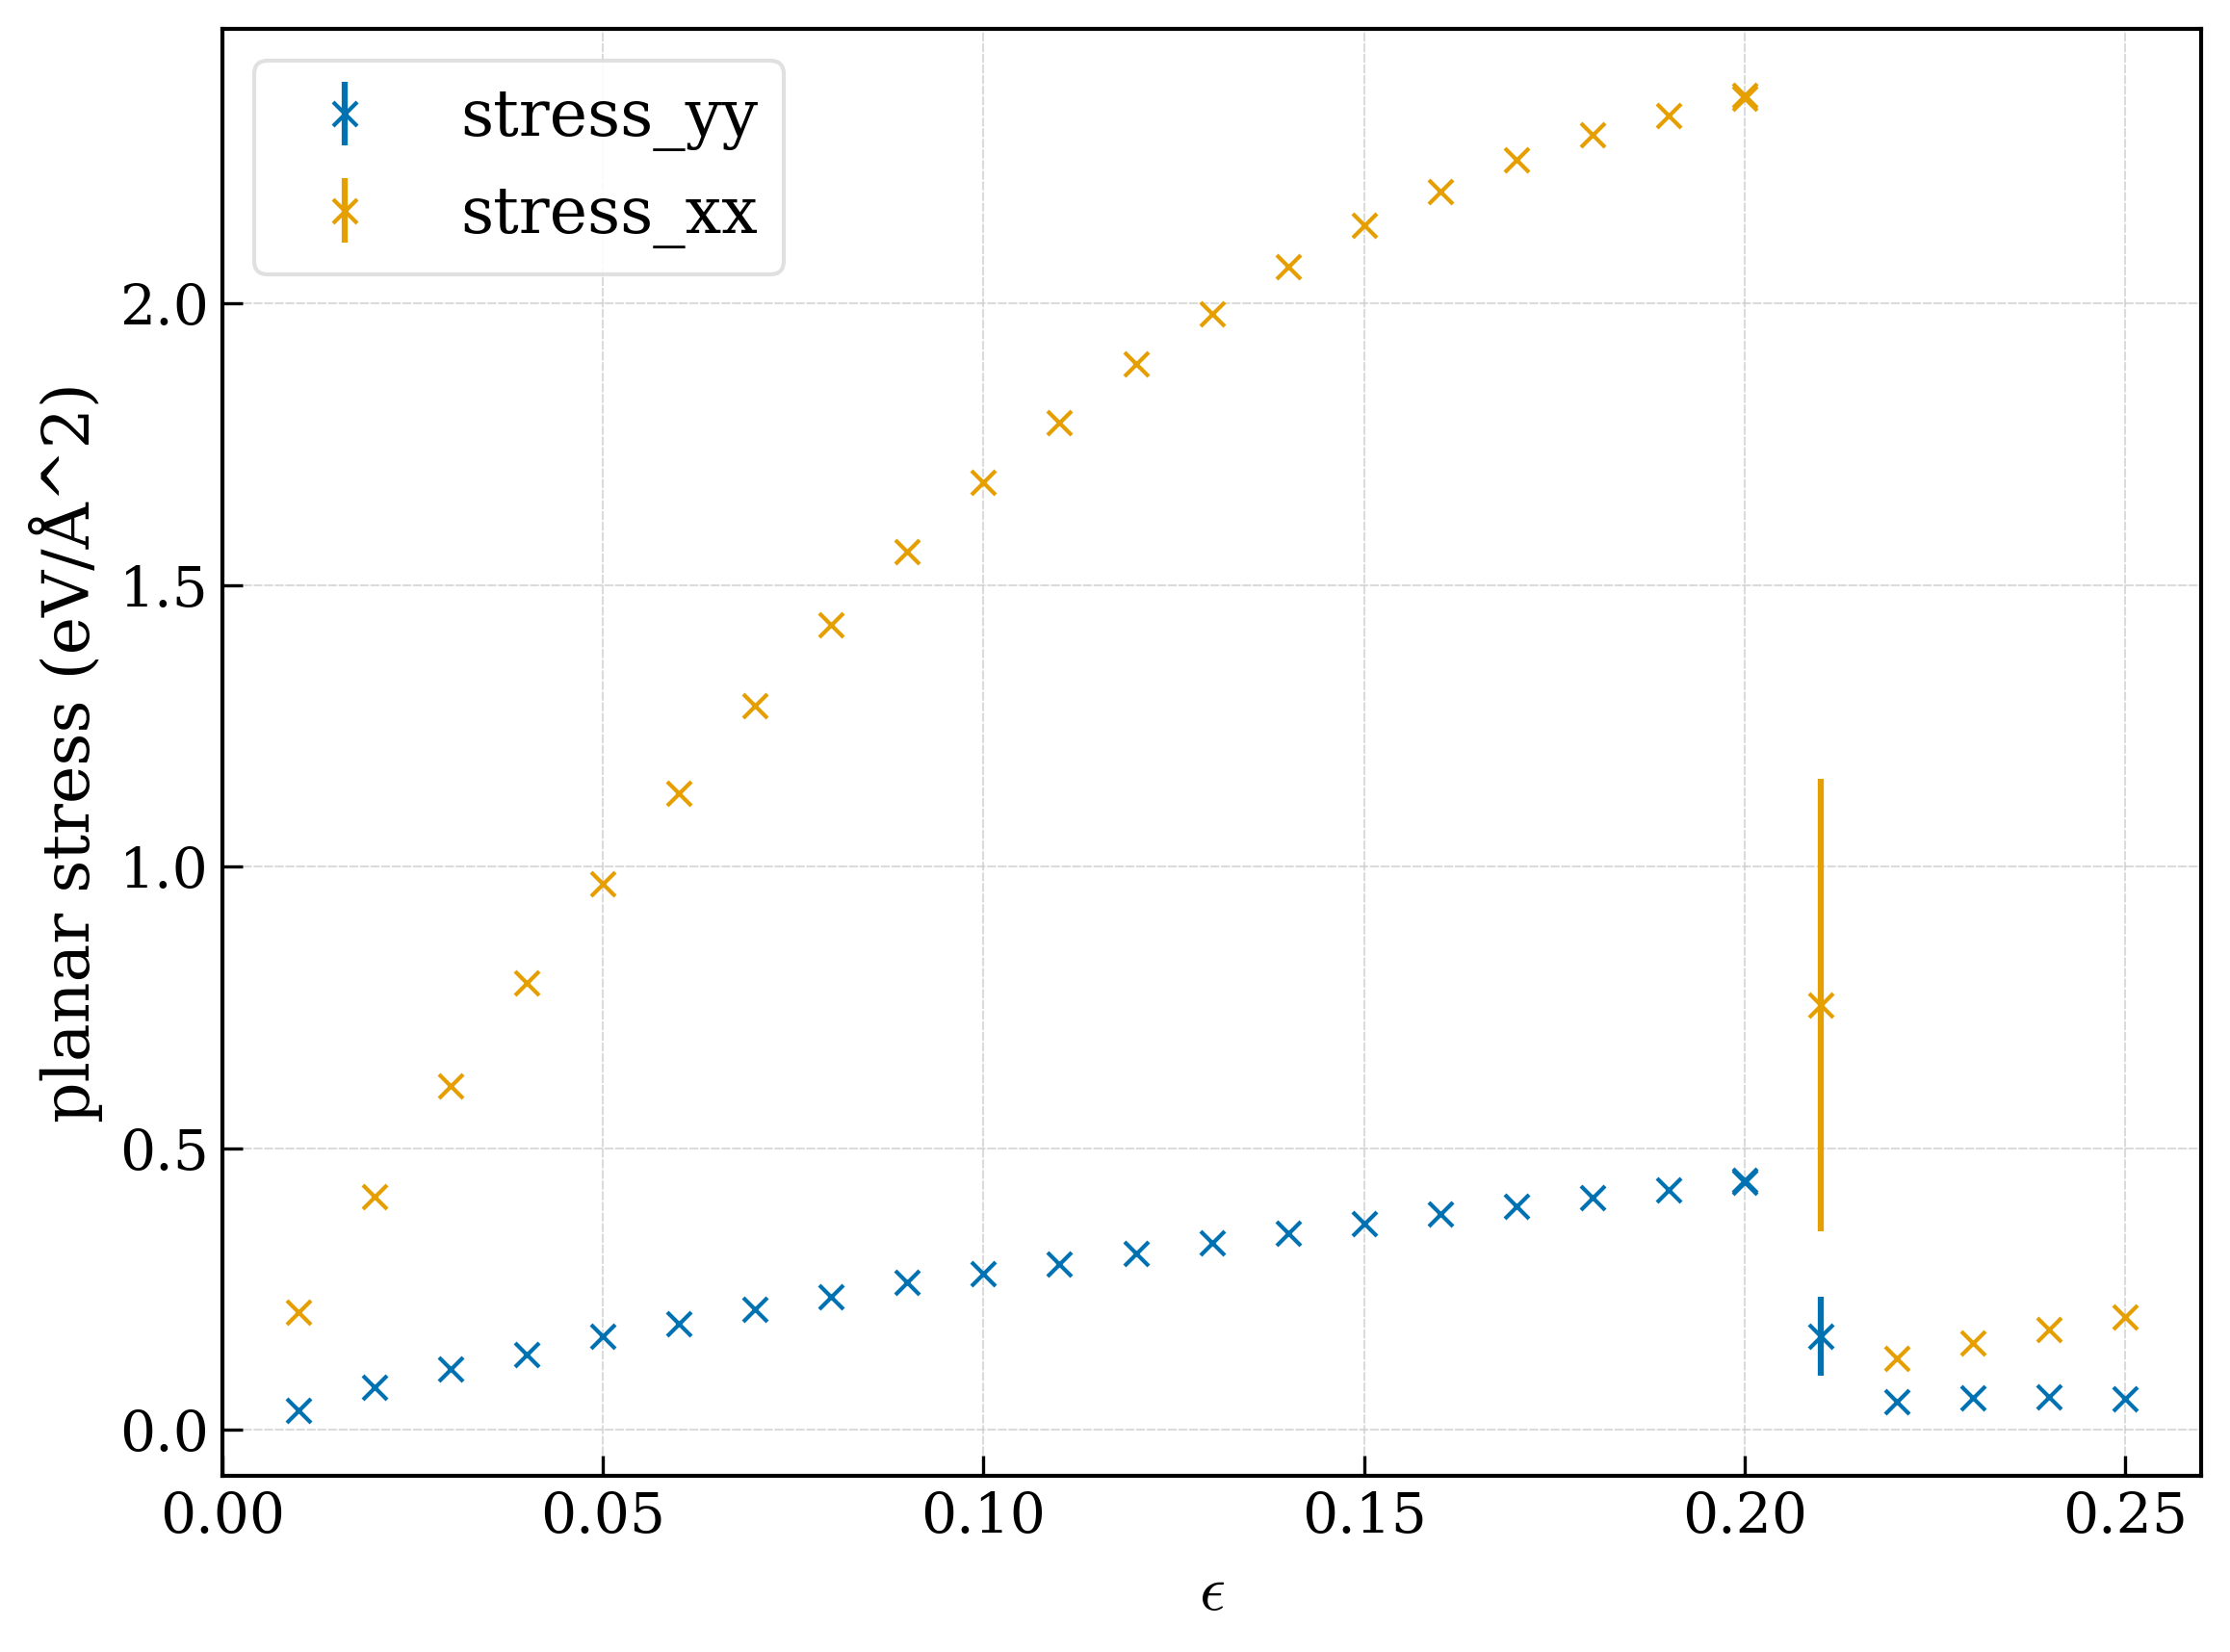

In [ ]:
plt.errorbar(strains, stress_yy_means, yerr=stress_yy_stds, label="stress_yy", marker="x", linestyle="")
plt.errorbar(strains, stress_xx_means, yerr=stress_xx_stds, label="stress_xx", marker="x", linestyle="")

plt.xlim((0, 0.26))
plt.grid(True)
plt.xlabel(r"$\epsilon$")
plt.ylabel("planar stress (eV/Å^2)")
plt.legend()
plt.tight_layout()
plt.savefig("STRAINSTRESS/strain_stress_xx.svg")

## Check Temperature

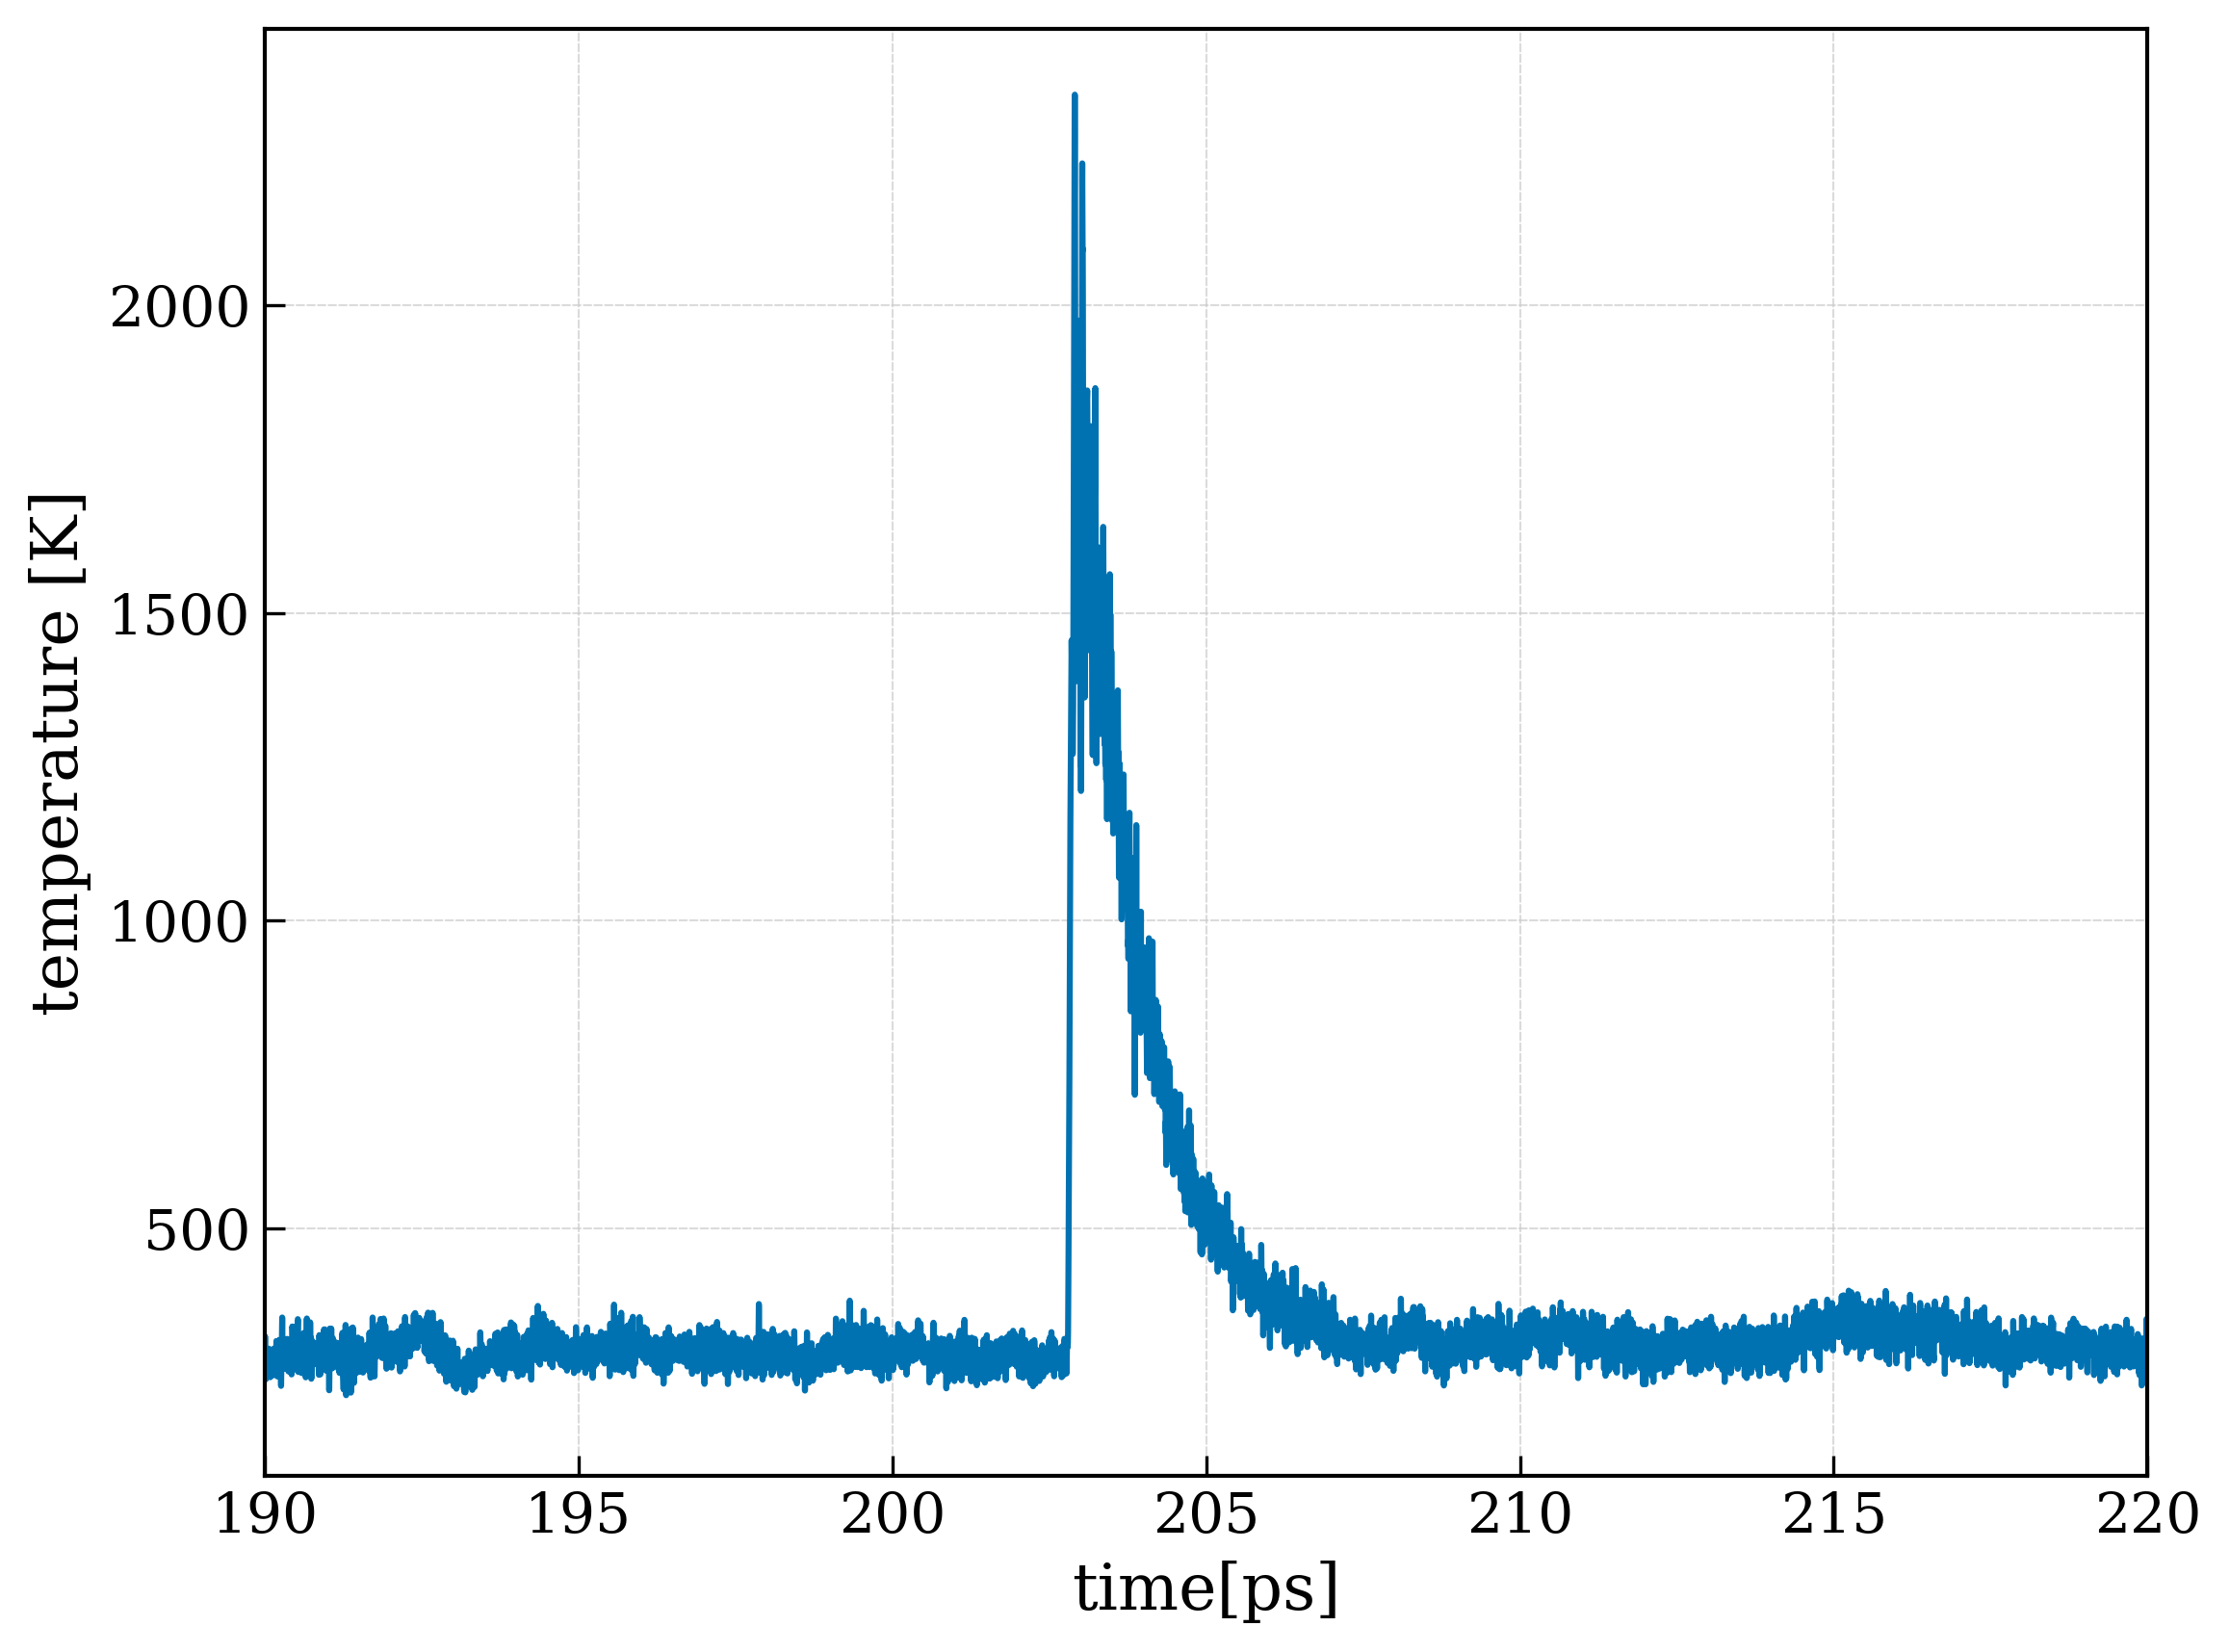

In [ ]:
temps = thermo["Temp"]
plt.plot(thermo["Step"].values.astype(float)*0.001,temps)
plt.xlim(190,220)


plt.xlabel("time[ps]")
plt.ylabel("temperature [K]")
plt.grid(True)
plt.tight_layout()
plt.savefig("STRAINSTRESS/temperature.svg")


## Check correlation time

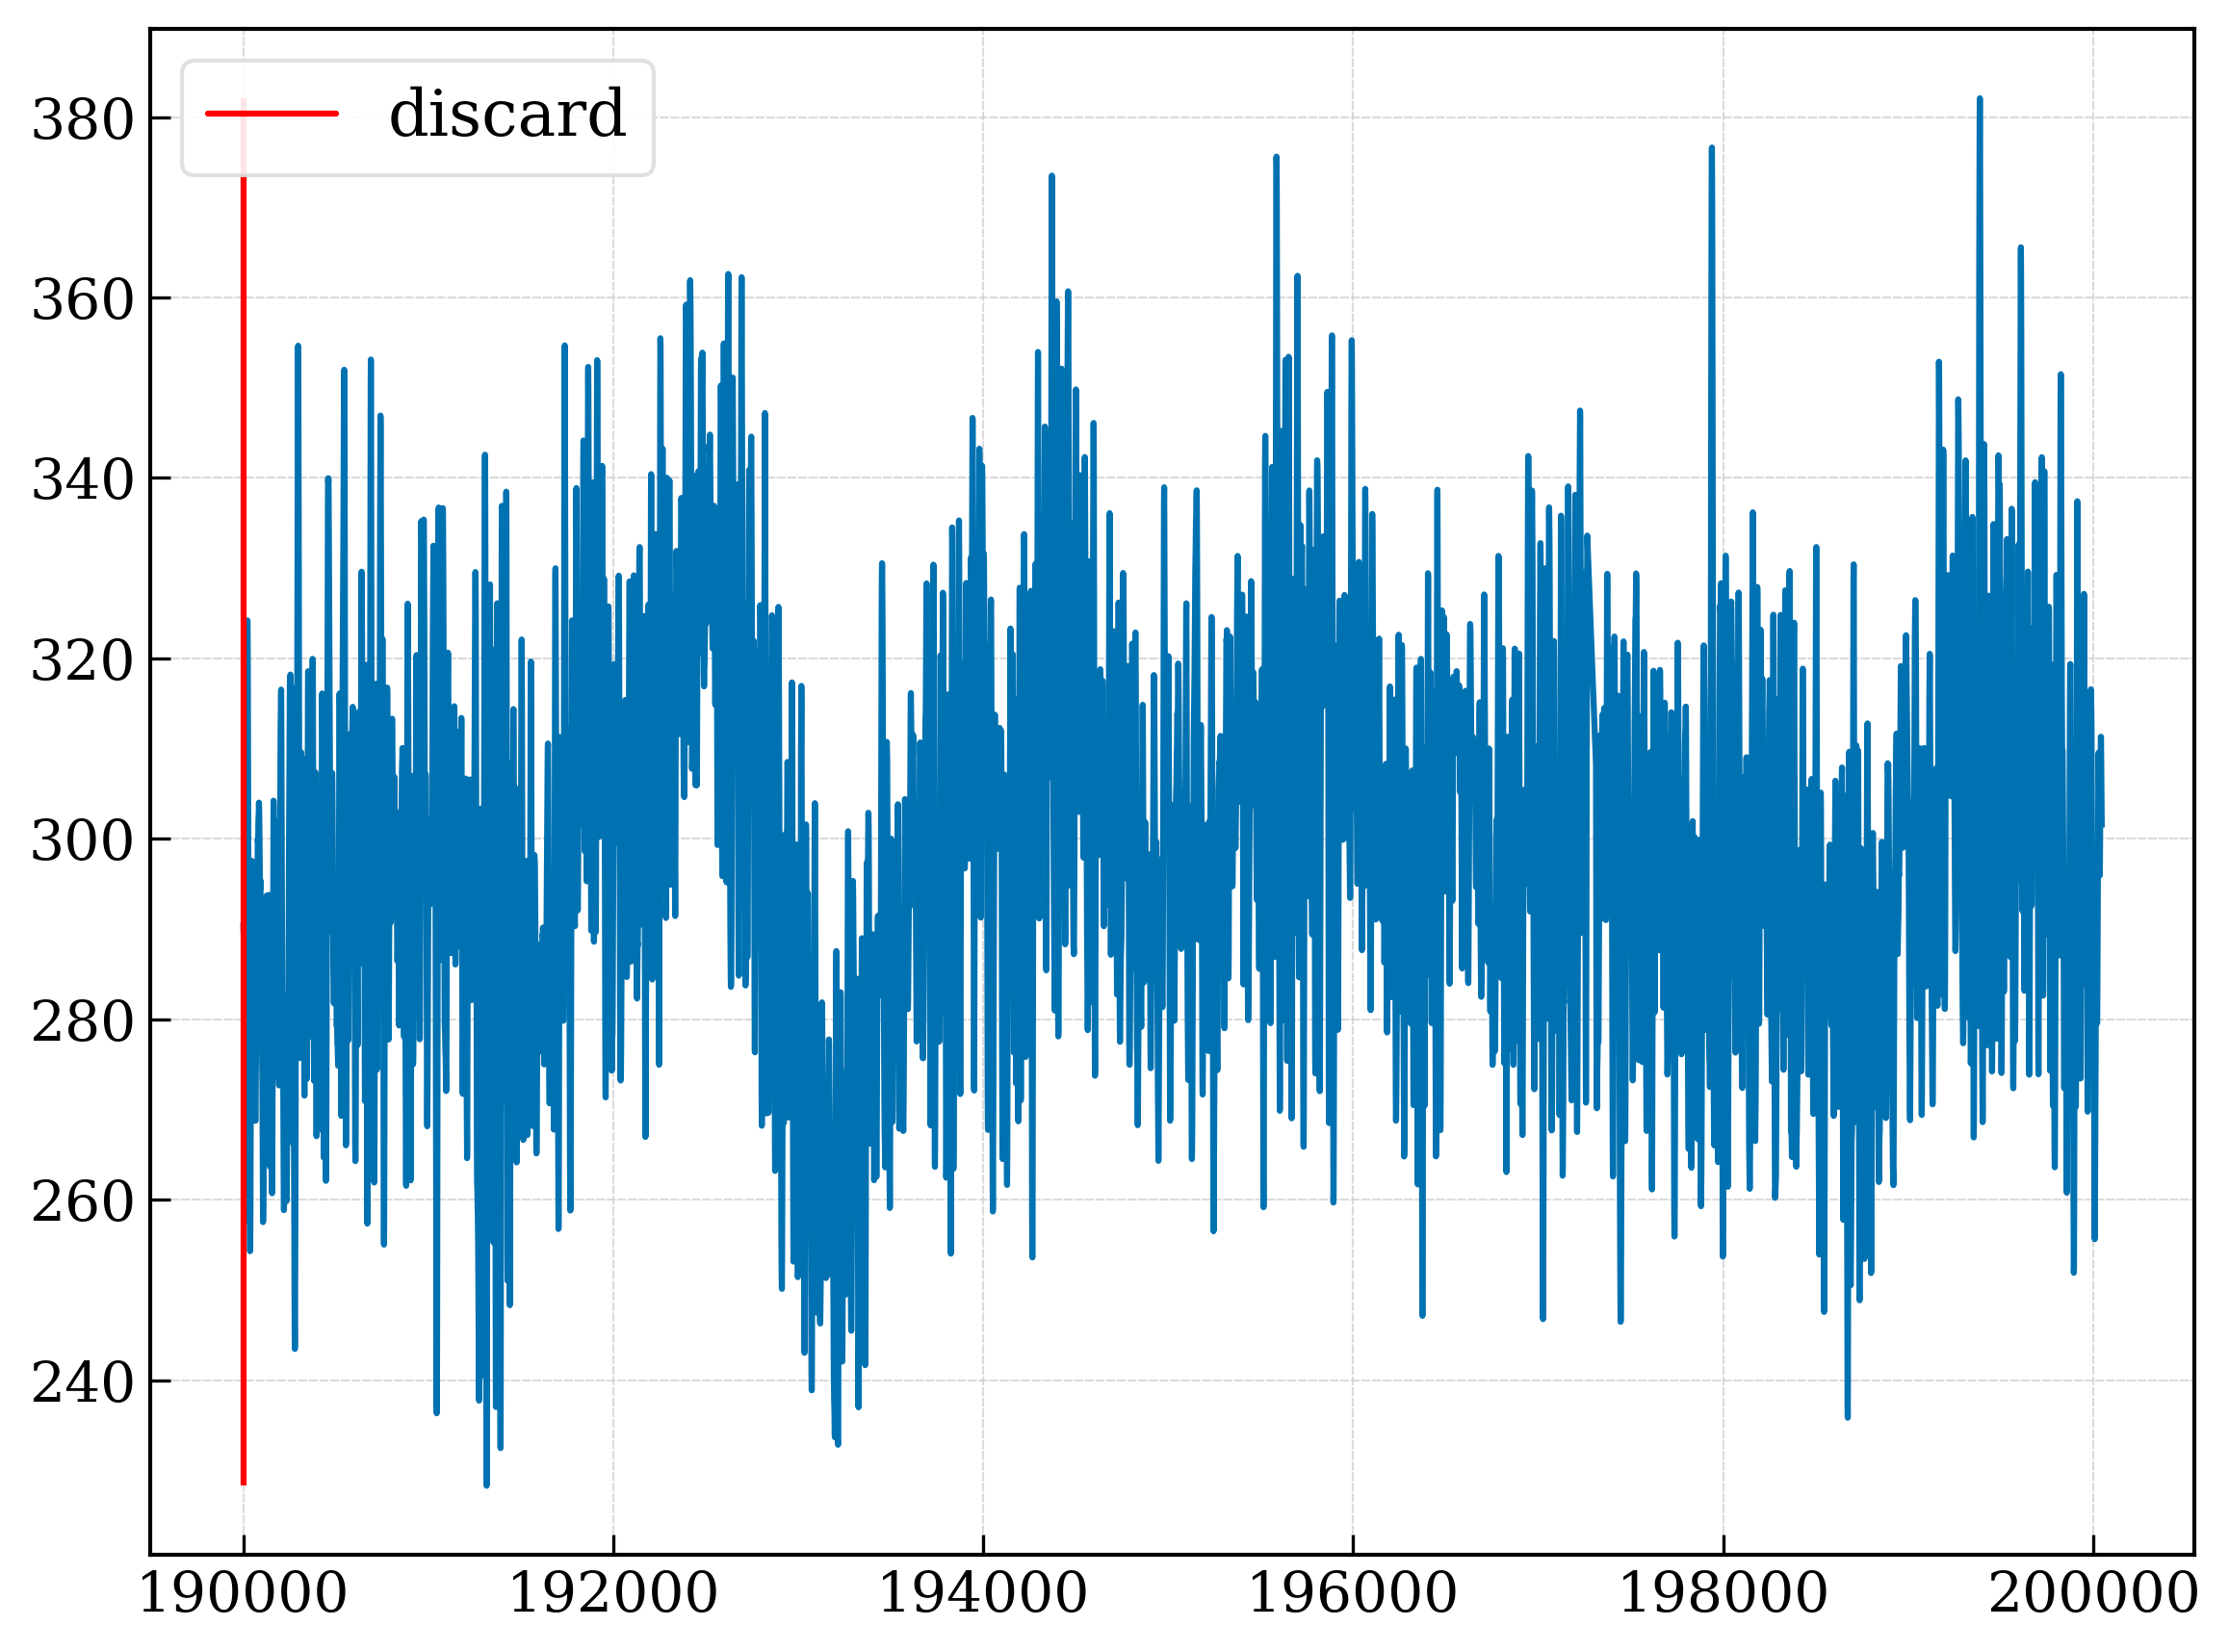

In [ ]:
nsteps = 10000 # number of steps at each strain
slice_idx = 19 # select the slice
timestep = 1e-3 # in pseconds seconds
discard = 0 # discard first steps that are correlated with previous equilibrium

times = np.linspace(0, timestep*nsteps, num=nsteps)
data = thermo['Temp'][slice_idx*nsteps:(slice_idx+1)*nsteps].astype(np.float64)
plt.plot(data)
plt.vlines(slice_idx*nsteps+discard, label = "discard", color = "red", ymin = np.min(data), ymax = np.max(data))

plt.legend()

data = data[discard:]
ndata = nsteps - discard
times = times[discard:]

Text(0.5, 0, 'frequency [THz]')

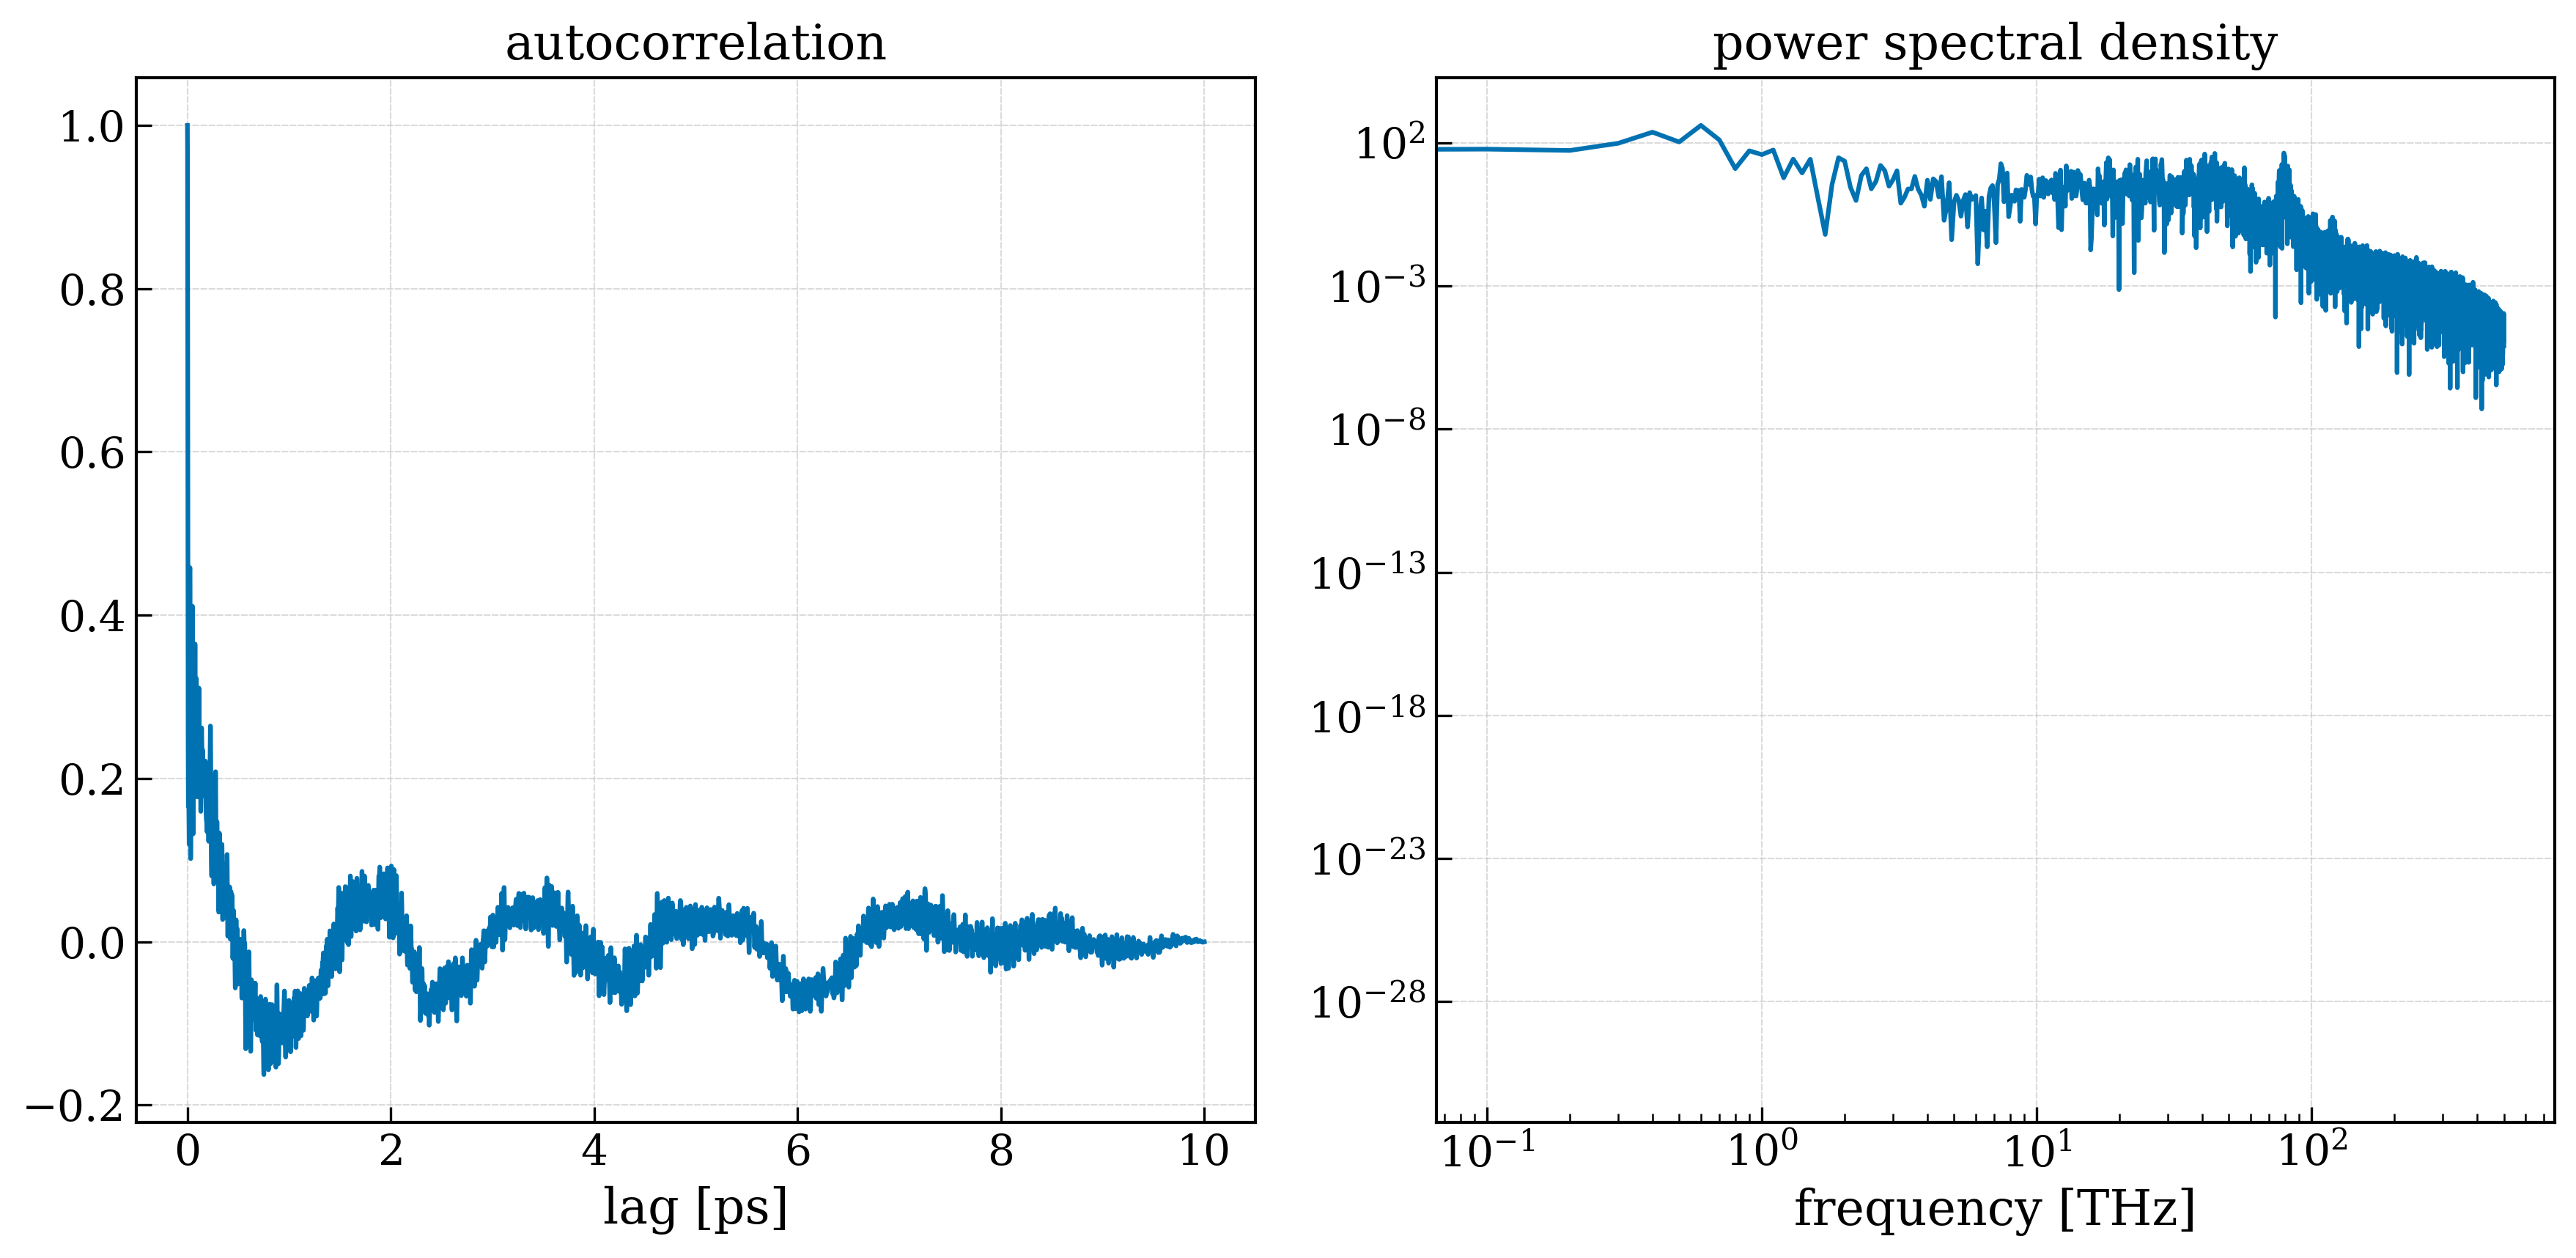

In [ ]:
# remove the mean
unbiased_data = data - np.mean(data)
autocorrelation = correlate(unbiased_data, unbiased_data, "full")[ndata-1:]
autocorrelation /= autocorrelation[0]
sampling_freq = 1/timestep
fs, psd = periodogram(unbiased_data, sampling_freq, return_onesided=True)

fix, axs = plt.subplots(1,2, figsize = (12,6))

axs[0].set_title("autocorrelation")
axs[0].plot(times - times[0], autocorrelation)
axs[0].set_xlabel("lag [ps]")

axs[1].set_title("power spectral density")
axs[1].plot(fs, psd)
axs[1].set_yscale("log")
axs[1].set_xscale("log")
axs[1].set_xlabel("frequency [THz]")

10 298.662585161 0.5724852603665305
100 298.6625851609999 1.2009227926079142
125 298.66258516100004 1.3203373965395309
250 298.662585161 1.766319753882677
500 298.66258516100004 2.1312680413602507
1000 298.662585161 2.5435711379332053
2500 298.66258516100004 1.2877557581518868


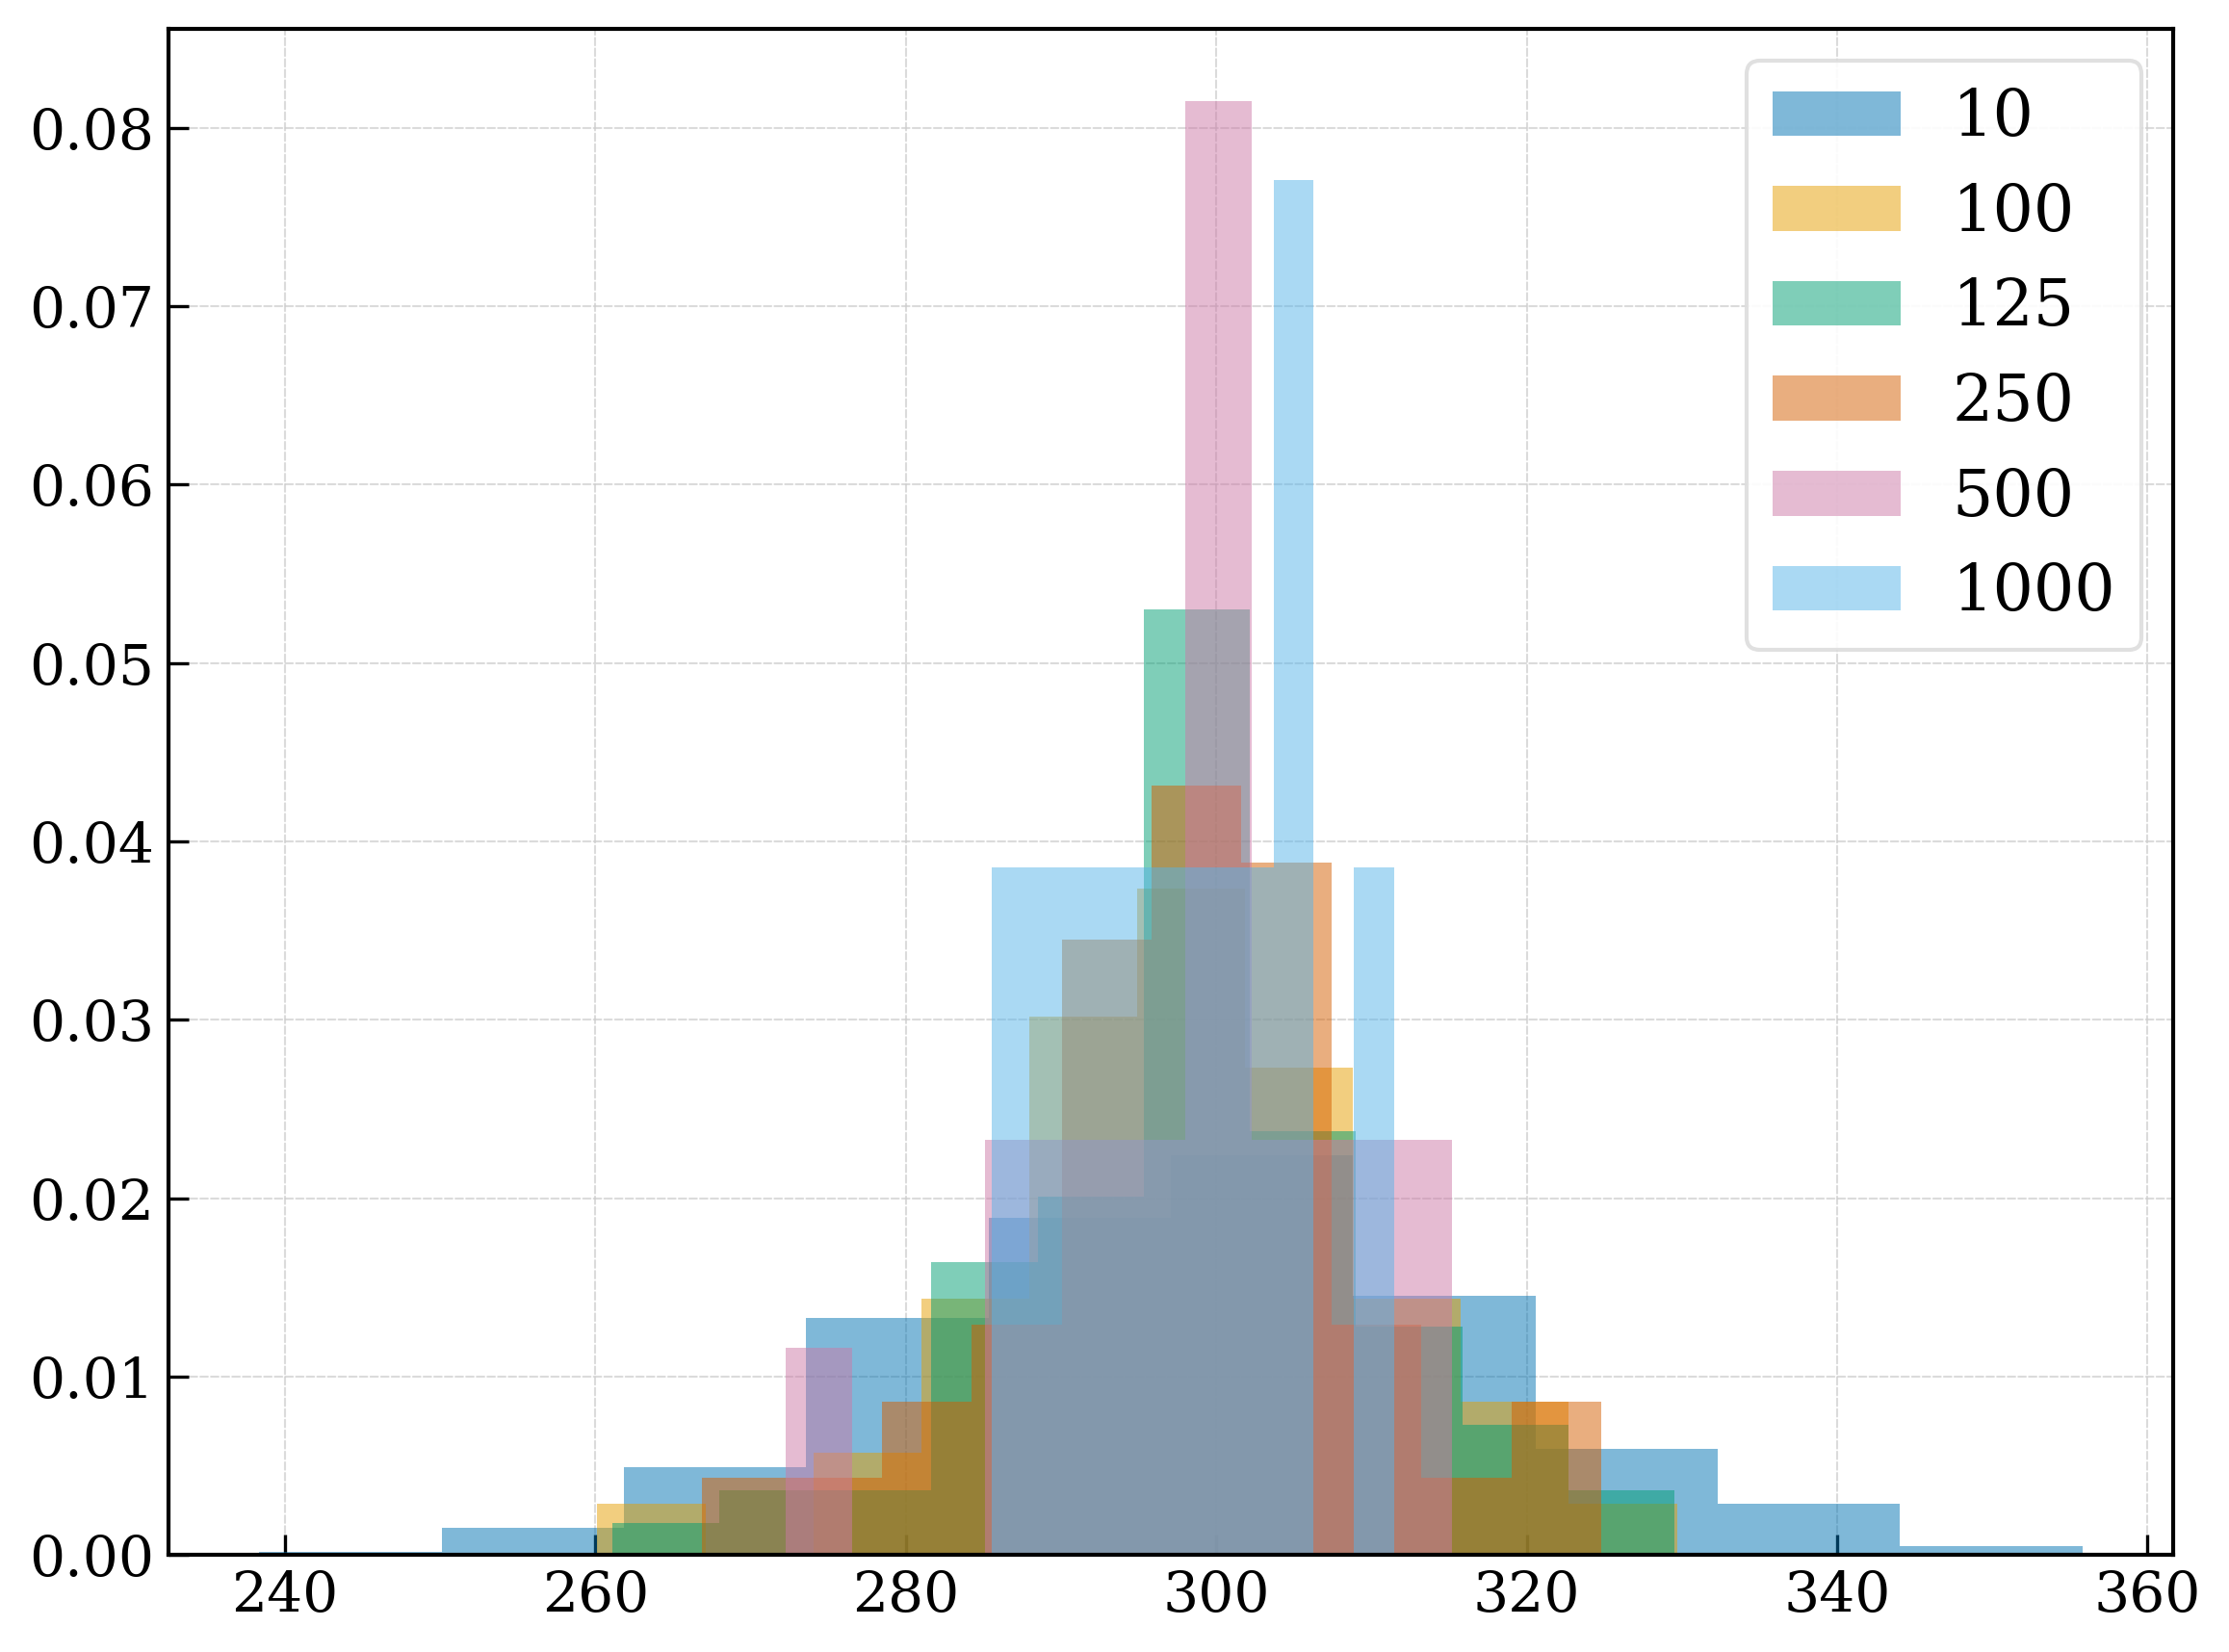

In [ ]:
from data_blocking import *

block_sizes = [10,100,125,250,500,1000,2500]

mus = []
stds = []

for bs in block_sizes:
    means = compute_blocks(np.asarray(data), bs)
    mean, std = meanstd(means)
    print(bs, mean, std)
    if bs in [10,100,125,250,500,1000,1500,2000, 3000]:
        plt.hist(means, label=bs, alpha=0.5, density=True)

    mus.append(mean)
    stds.append(std)

plt.legend()

Text(0, 0.5, 'mean uncertainty')

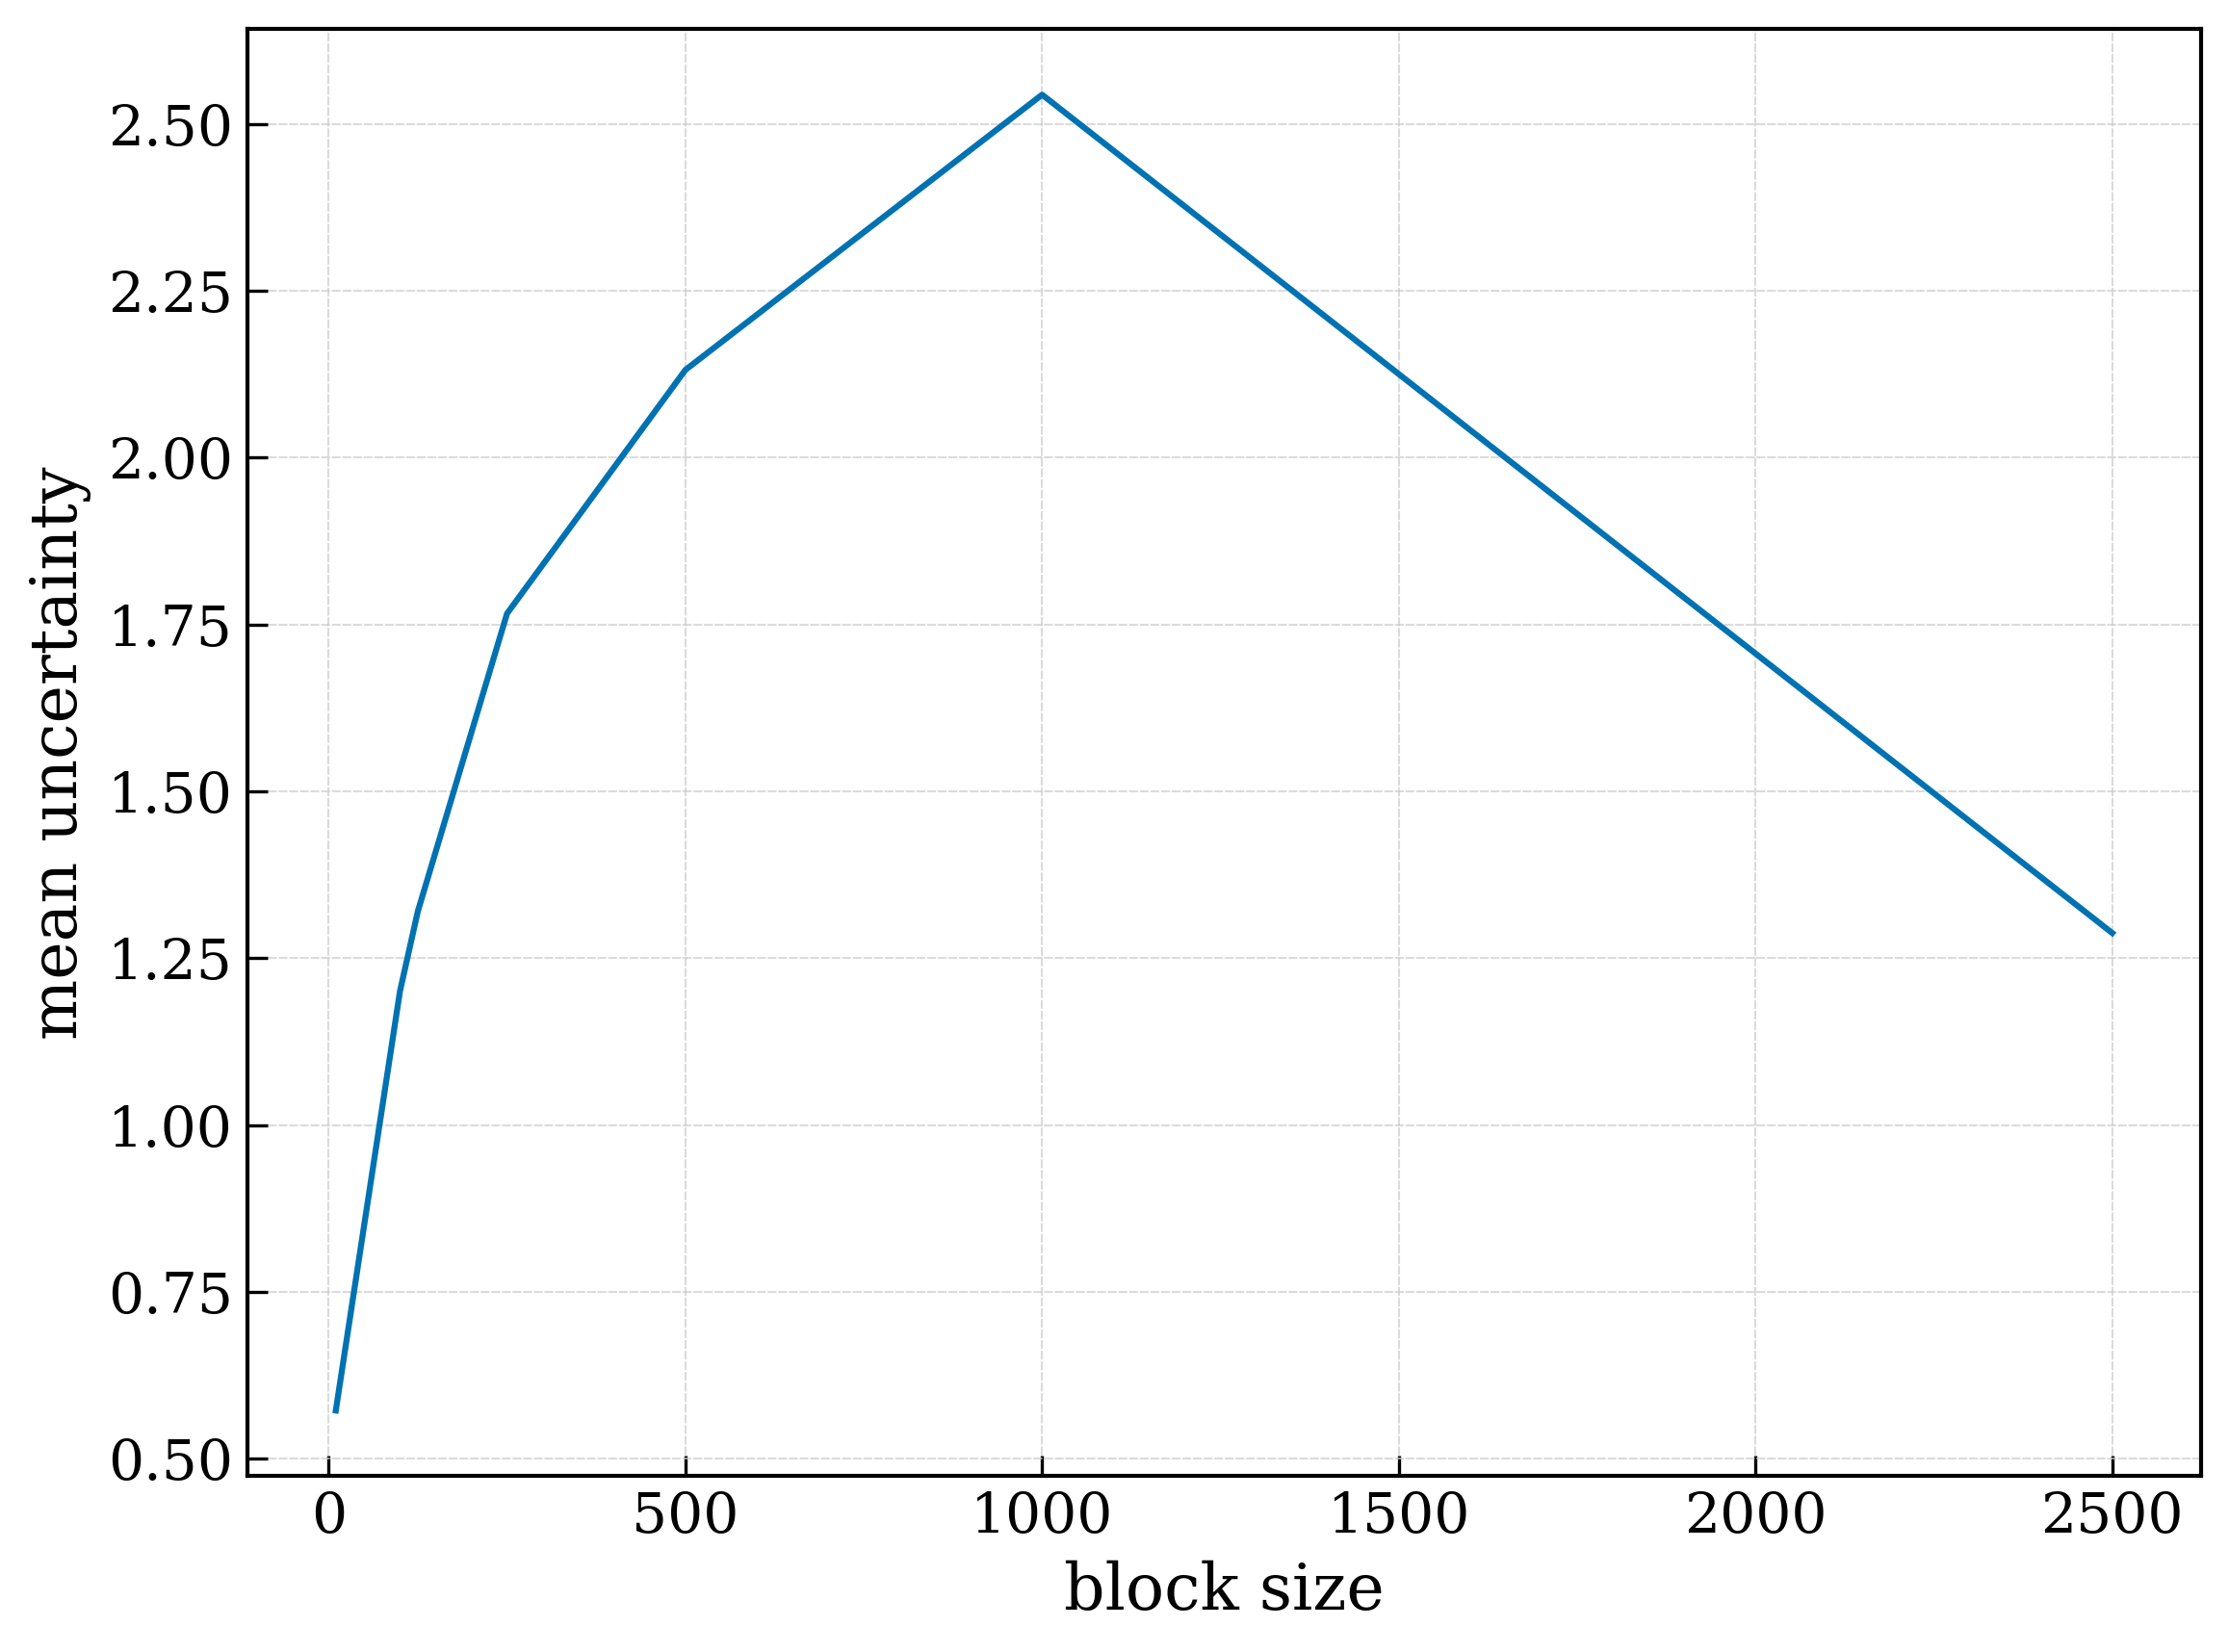

In [ ]:
plt.plot(block_sizes, stds)
plt.xlabel("block size")
plt.ylabel("mean uncertainty")